# Predicting Late Deliveries in a Global Supply Chain

**Author:** Ayesha
**Date:** April 2026

## What is this project about?
In this project, I'm looking at 180,000+ orders from a global company to find out 
why some deliveries arrive late. I want to identify recurring patterns behind these 
delays and build a model that can predict late deliveries before they happen. 
Finally, I'll suggest potential solutions to help the company reduce late deliveries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All libraries loaded!")

All libraries loaded!


In [2]:
df = pd.read_csv('archive/DataCoSupplyChainDataset.csv', encoding='latin-1')
df.shape

(180519, 53)

In [3]:
import os
os.listdir()

['.DS_Store', 'archive', 'Untitled.ipynb', '.ipynb_checkpoints']

In [4]:
os.listdir('archive')

['tokenized_access_logs.csv',
 'DataCoSupplyChainDataset.csv',
 'DescriptionDataCoSupplyChain.csv']

In [5]:
df = pd.read_csv('archive/DataCoSupplyChainDataset.csv', encoding='latin-1')
df.shape

(180519, 53)

In [6]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

### Understanding the Columns
The dataset has 53 columns. The most important ones for my analysis are:
- **Delivery Status** and **Late_delivery_risk** — what I'm trying to predict
- **Shipping Mode** — how the order was shipped
- **Days for shipping (real) vs (scheduled)** — actual vs planned delivery time
- **Order Region** — where the order was going

In [8]:
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [9]:
98977 / 180519 * 100

54.82913155955883

### 54% is a huge number. Means more than half of the orders result in late deliveries.
The breakdown:
- Late delivery: ~99,000 orders (55%)
- Advance shipping: ~41,600 orders (23%)
- Shipping on time: ~32,200 orders (18%)
- Shipping canceled: ~7,750 orders (4%)

In [10]:
df['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [11]:
pd.crosstab(df['Shipping Mode'], df['Delivery Status'])

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping Mode,,,,
First Class,0,26513,1301,0
Same Day,0,4454,444,4839
Second Class,0,26987,1410,6819
Standard Class,41592,41023,4599,20538


In [12]:
pd.crosstab(df['Shipping Mode'], df['Delivery Status'], normalize='index').round(2) * 100

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping Mode,,,,
First Class,0.0,95.0,5.0,0.0
Same Day,0.0,46.0,5.0,50.0
Second Class,0.0,77.0,4.0,19.0
Standard Class,39.0,38.0,4.0,19.0


### Surprising Finding: First Class has the worst delivery record
I expected First Class shipping to have the best on-time rate since 
customers pay more for it. But the data shows the opposite. 95% of 
First Class orders are late. 

This raises important questions:
- Is the company overpromising delivery times for premium shipping?
- Are the scheduled delivery windows too tight for First Class?
- Is there any other external factor, like the delivery method, that has anything to do with the late deliveries?
- Are there patterns in order status (fraud, cancellations, holds) that relate to delivery performance?

In [13]:
df.groupby('Shipping Mode')[['Days for shipping (real)', 'Days for shipment (scheduled)']].mean().round(1)

,Days for shipping (real),Days for shipment (scheduled)
Shipping Mode,,
First Class,2.0,1.0
Same Day,0.5,0.0
Second Class,4.0,2.0
Standard Class,4.0,4.0


### Why are deliveries late?
The company is setting unrealistic delivery promises for premium shipping modes.
First Class promises 1 day but takes 2. Second Class promises 2 days but takes 4.
Standard Class is the only mode where the promise matches reality (4 days = 4 days).

The problem isn't slow shipping, it's overpromising.

In [14]:
df['Order Region'].value_counts()

Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Eastern Asia        7280
East of USA         6915
West Asia           6009
US Center           5887
South of  USA       4045
Eastern Europe      3920
West Africa         3696
North Africa        3232
East Africa         1852
Central Africa      1677
Southern Africa     1157
Canada               959
Central Asia         553
Name: count, dtype: int64

In [15]:
pd.crosstab(df['Order Region'], df['Delivery Status'], normalize='index').round(2) * 100

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Order Region,,,,
Canada,29.0,49.0,5.0,16.0
Caribbean,24.0,53.0,4.0,19.0
Central Africa,21.0,58.0,4.0,17.0
Central America,23.0,55.0,4.0,18.0
Central Asia,20.0,55.0,2.0,22.0
East Africa,22.0,56.0,4.0,19.0
East of USA,23.0,56.0,4.0,17.0
Eastern Asia,24.0,54.0,4.0,17.0
Eastern Europe,22.0,56.0,3.0,18.0


### Does region affect late deliveries?
Late delivery rates are remarkably similar across all 23 regions (49%-58%). 
This tells me the problem is NOT location-specific. It's a system issue.
If it were a regional problem, we'd see one or two regions with much higher rates. 
Instead, the company has been consistently delivering late across the board.

This supports my earlier finding. The root cause is likely the unrealistic 
delivery promises, not the shipping routes or distances.

In [16]:
late_by_category = df.groupby('Category Name')['Late_delivery_risk'].mean().sort_values(ascending=False).round(2) * 100

print(late_by_category)

Category Name
Golf Bags & Carts       69.0
Lacrosse                60.0
Pet Supplies            59.0
Cameras                 58.0
Strength Training       58.0
As Seen on  TV!         57.0
Music                   57.0
Accessories             57.0
Fitness Accessories     57.0
Books                   57.0
Women's Clothing        56.0
Boxing & MMA            56.0
Golf Gloves             56.0
Hunting & Shooting      56.0
Electronics             56.0
Crafts                  56.0
Health and Beauty       56.0
Tennis & Racquet        56.0
Garden                  56.0
Trade-In                56.0
Golf Shoes              56.0
Sporting Goods          55.0
Girls' Apparel          55.0
Basketball              55.0
Baseball & Softball     55.0
Consumer Electronics    55.0
Shop By Sport           55.0
Toys                    55.0
Cleats                  55.0
Fishing                 55.0
Water Sports            55.0
Indoor/Outdoor Games    55.0
Golf Balls              55.0
Women's Apparel         55.0


### Does product category matter?
Most categories have similar late delivery rates (52-58%). 
This further confirms that late deliveries are a system-wide issue, 
not caused by specific products or locations.

### Data Limitation & Recommendation
The dataset doesn't include information about which delivery partners 
(e.g., FedEx, DHL, UPS) handle each shipment. If this data were available, 
we could analyze whether the late delivery problem is caused by a specific 
courier partner, especially for First Class shipping, where 95% of orders 
are late. 

**Recommendation to the company:** Start tracking which delivery partner 
handles each order. This would allow a deeper investigation into whether 
switching partners could solve the late delivery issue.

In [17]:
df['Type'].value_counts()

Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

In [18]:
pd.crosstab(df['Type'], df['Delivery Status'], normalize='index').round(2) * 100

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Type,,,,
CASH,25.0,57.0,0.0,19.0
DEBIT,24.0,57.0,0.0,19.0
PAYMENT,24.0,58.0,0.0,18.0
TRANSFER,20.0,49.0,16.0,15.0


### Payment Type Analysis
Most payment types show similar late delivery rates (57-58%). 
However, TRANSFER stands out. It has a 16% cancellation rate, while all other payment types have 0%. 

This suggests transfer payments may have processing issues 
(failed payments, fraud flags, or verification delays) that lead 
to order cancellations. This needs further investigation.

In [19]:
df['Order Status'].value_counts()

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [20]:
pd.crosstab(df['Order Status'], df['Delivery Status'], normalize='index').round(2) * 100

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Order Status,,,,
CANCELED,0.0,0.0,100.0,0.0
CLOSED,25.0,57.0,0.0,19.0
COMPLETE,24.0,57.0,0.0,19.0
ON_HOLD,25.0,56.0,0.0,20.0
PAYMENT_REVIEW,22.0,57.0,0.0,21.0
PENDING,24.0,58.0,0.0,18.0
PENDING_PAYMENT,24.0,58.0,0.0,18.0
PROCESSING,25.0,57.0,0.0,18.0
SUSPECTED_FRAUD,0.0,0.0,100.0,0.0


### Order Status & Fraud Analysis
Orders flagged as SUSPECTED_FRAUD or CANCELED are never shipped (100% canceled).
All other order statuses show nearly identical late delivery rates (56-58%), 
including orders that were put ON_HOLD or sent to PAYMENT_REVIEW.

Key insight: Holding orders for review does NOT increase late delivery risk. 
The late delivery problem exists equally across all active order statuses, 
which again points to a system-wide issue rather than specific order types.

### Data Cleaning & Preprocessing
Before building a prediction model, I need to clean the data, handle missing values, remove unnecessary columns, and prepare 
everything for analysis.

In [21]:
df.isnull().sum().sort_values(ascending=False).head(15)

Product Description         180519
Order Zipcode               155679
Customer Lname                   8
Customer Zipcode                 3
Type                             0
Order Profit Per Order           0
Order Item Cardprod Id           0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Id                    0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales                            0
Order Item Total                 0
dtype: int64

In [22]:
columns_to_drop = [
    'Product Description',    # 100% empty
    'Order Zipcode',          # 86% empty
    'Customer Email',         # personal info, not useful
    'Customer Password',      # personal info, not useful
    'Customer Lname',         # name doesn't affect delivery
    'Customer Fname',         # name doesn't affect delivery
    'Customer Street',        # too specific, not useful
    'Product Image',          # image links, not useful
    'Customer Id',            # just an ID number
    'Order Customer Id',      # duplicate ID
    'Order Item Id',          # just an ID number
    'Product Card Id',        # just an ID number
    'Order Item Cardprod Id', # just an ID number
]

df_clean = df.drop(columns=columns_to_drop)
print(f"Before: {df.shape[1]} columns")
print(f"After: {df_clean.shape[1]} columns")
print(f"Dropped: {len(columns_to_drop)} columns")

Before: 53 columns
After: 40 columns
Dropped: 13 columns


In [23]:
df_clean.isnull().sum().sum()

np.int64(3)

In [24]:
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

Customer Zipcode    3
dtype: int64

In [25]:
df_clean = df_clean.dropna()
print(f"Rows before: 180519")
print(f"Rows after: {df_clean.shape[0]}")
print(f"Rows removed: {180519 - df_clean.shape[0]}")

Rows before: 180519
Rows after: 180516
Rows removed: 3


In [26]:
df_clean = df_clean[~df_clean['Order Status'].isin(['SUSPECTED_FRAUD', 'CANCELED'])]
print(f"Rows after removing fraud & canceled: {df_clean.shape[0]}")

Rows after removing fraud & canceled: 172762


## Data Cleaning Summary
- Started with 180,519 rows and 53 columns
- Dropped 13 useless columns (empty data, personal info, ID numbers) → 40 columns
- Removed 3 rows with missing Customer Zipcode → 180,516 rows
- Removed 7,754 SUSPECTED_FRAUD and CANCELED orders (never shipped) → 172,762 rows
- Final clean dataset: 172,762 rows × 40 columns

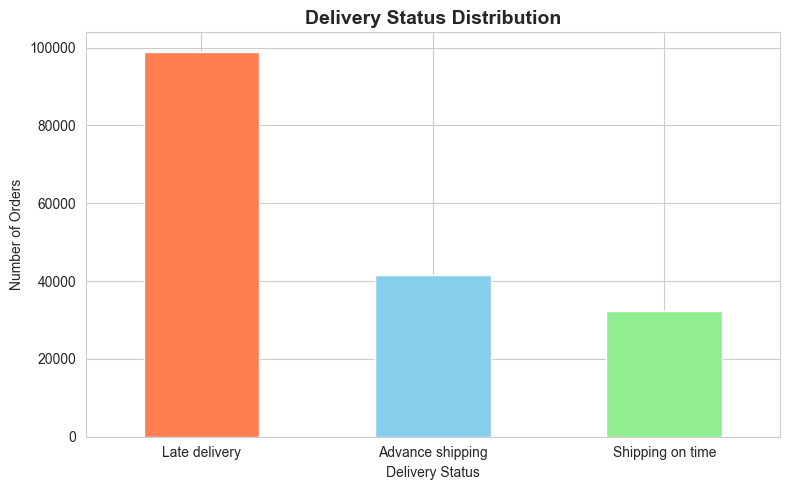

In [27]:
plt.figure(figsize=(8, 5))
df_clean['Delivery Status'].value_counts().plot(kind='bar', color=['coral', 'skyblue', 'lightgreen'])
plt.title('Delivery Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

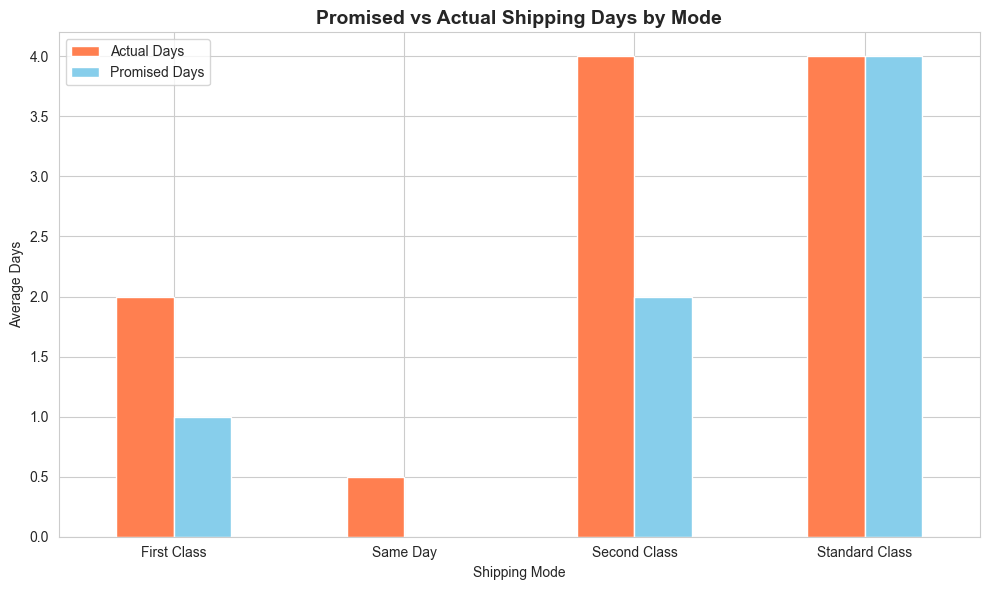

In [28]:
ship_times = df_clean.groupby('Shipping Mode')[['Days for shipping (real)', 'Days for shipment (scheduled)']].mean().round(1)

ship_times.plot(kind='bar', figsize=(10, 6), color=['coral', 'skyblue'])
plt.title('Promised vs Actual Shipping Days by Mode', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Days')
plt.xticks(rotation=0)
plt.legend(['Actual Days', 'Promised Days'])
plt.tight_layout()
plt.show()

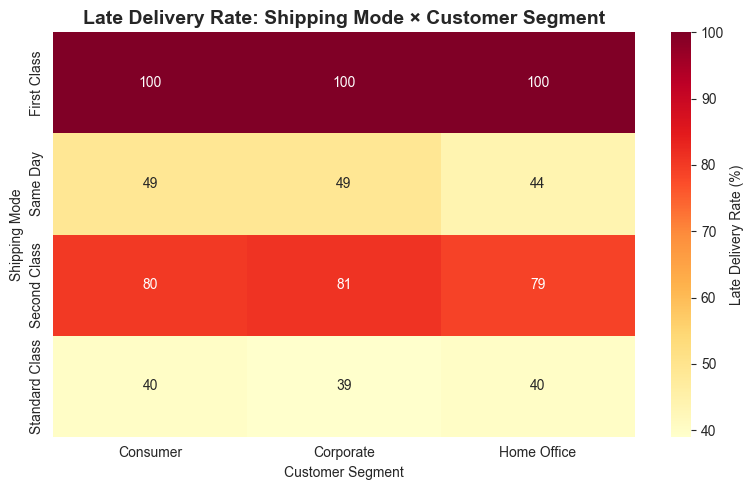

In [29]:
heatmap_data = pd.crosstab(
    df_clean['Shipping Mode'], 
    df_clean['Customer Segment'], 
    values=df_clean['Late_delivery_risk'], 
    aggfunc='mean'
).round(2) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Late Delivery Rate (%)'})
plt.title('Late Delivery Rate: Shipping Mode × Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Heatmap Insight
First Class shipping has a 100% late delivery rate regardless of customer type.
The customer segment (Consumer, Corporate, Home Office) has almost no impact on 
whether a delivery is late. The shipping mode is the dominant factor.

In [30]:
df_clean['shipping_delay'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']
df_clean['shipping_delay'].describe()

count    172762.000000
mean          0.565501
std           1.493253
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: shipping_delay, dtype: float64

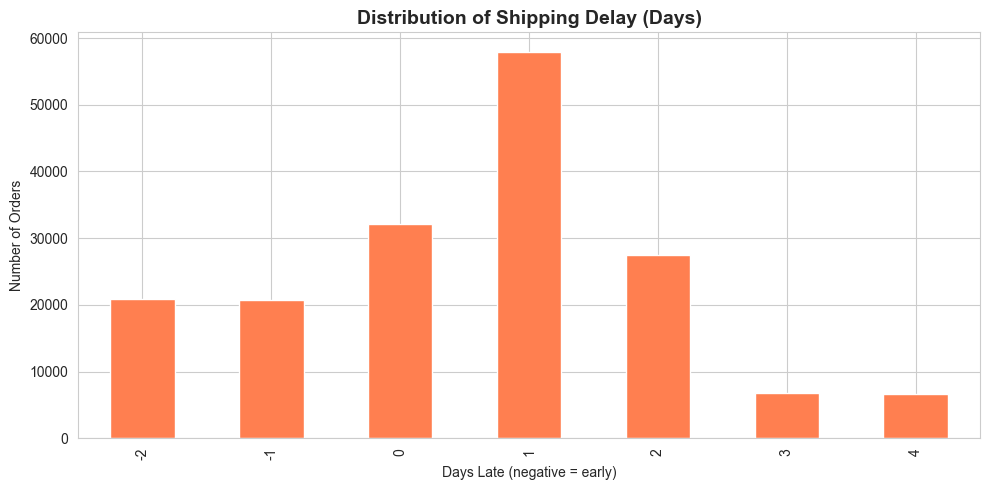

In [31]:
plt.figure(figsize=(10, 5))
df_clean['shipping_delay'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='white')
plt.title('Distribution of Shipping Delay (Days)', fontsize=14, fontweight='bold')
plt.xlabel('Days Late (negative = early)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### Shipping Delay Distribution
Most late deliveries are only 1 day behind schedule (~58,000 orders). 
This means the company could significantly reduce its late delivery rate 
by simply adding 1 day to its promised delivery times. A small change 
in expectations could turn thousands of "late" deliveries into "on time."

In [32]:
df_clean['is_late'] = (df_clean['Late_delivery_risk'] == 1).astype(int)
df_clean['is_late'].value_counts()

is_late
1    98976
0    73786
Name: count, dtype: int64

## Phase 6: Predictive Modeling
Now I'll build a machine learning model that can predict whether an order 
will be delivered late BEFORE it ships. This could help the company take 
action on orders that are likely to be late.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Scikit-learn loaded!")

Scikit-learn loaded!


In [34]:
features = ['Days for shipment (scheduled)', 'Order Item Quantity', 
            'Order Item Discount Rate', 'Product Price', 
            'Order Item Profit Ratio', 'Sales']

X = df_clean[features]
y = df_clean['is_late']

print("Features we're using as clues:")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")
print(f"\nTotal features: {len(features)}")
print(f"Total orders: {len(X)}")

Features we're using as clues:
  1. Days for shipment (scheduled)
  2. Order Item Quantity
  3. Order Item Discount Rate
  4. Product Price
  5. Order Item Profit Ratio
  6. Sales

Total features: 6
Total orders: 172762


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Study flashcards: {len(X_train)} orders")
print(f"Exam flashcards: {len(X_test)} orders")

Study flashcards: 138209 orders
Exam flashcards: 34553 orders


In [36]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [37]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 64.71%


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.63      0.60     14637
           1       0.71      0.66      0.68     19916

    accuracy                           0.65     34553
   macro avg       0.64      0.64      0.64     34553
weighted avg       0.65      0.65      0.65     34553



In [39]:
df_model = df_clean.copy()

df_model['Shipping Mode Encoded'] = df_model['Shipping Mode'].map({
    'Same Day': 0,
    'First Class': 1,
    'Second Class': 2,
    'Standard Class': 3
})

print(df_model['Shipping Mode Encoded'].value_counts())

Shipping Mode Encoded
3    103151
2     33806
1     26512
0      9293
Name: count, dtype: int64


In [40]:
features_v2 = ['Days for shipment (scheduled)', 'Shipping Mode Encoded',
               'Order Item Quantity', 'Order Item Discount Rate', 
               'Product Price', 'Order Item Profit Ratio', 'Sales']

X = df_model[features_v2]
y = df_model['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(X_train, y_train)

y_pred_v2 = model_v2.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_v2):.2%}")
print()
print(classification_report(y_test, y_pred_v2))

Accuracy: 64.73%

              precision    recall  f1-score   support

           0       0.58      0.63      0.60     14637
           1       0.71      0.66      0.68     19916

    accuracy                           0.65     34553
   macro avg       0.64      0.64      0.64     34553
weighted avg       0.65      0.65      0.65     34553



In [41]:
df_model2 = pd.get_dummies(df_clean, columns=['Shipping Mode'], dtype=int)

print("New shipping columns:")
print([col for col in df_model2.columns if 'Shipping' in col])

New shipping columns:
['Shipping Mode_First Class', 'Shipping Mode_Same Day', 'Shipping Mode_Second Class', 'Shipping Mode_Standard Class']


In [42]:
features_v3 = ['Days for shipment (scheduled)', 'Order Item Quantity', 
               'Order Item Discount Rate', 'Product Price', 
               'Order Item Profit Ratio', 'Sales',
               'Shipping Mode_First Class', 'Shipping Mode_Same Day', 
               'Shipping Mode_Second Class', 'Shipping Mode_Standard Class']

X = df_model2[features_v3]
y = df_model2['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_v3 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v3.fit(X_train, y_train)

y_pred_v3 = model_v3.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_v3):.2%}")
print()
print(classification_report(y_test, y_pred_v3))

Accuracy: 64.78%

              precision    recall  f1-score   support

           0       0.58      0.63      0.60     14637
           1       0.71      0.66      0.68     19916

    accuracy                           0.65     34553
   macro avg       0.64      0.65      0.64     34553
weighted avg       0.65      0.65      0.65     34553



In [43]:
from sklearn.tree import DecisionTreeClassifier

features_v4 = ['Days for shipment (scheduled)', 'Order Item Quantity', 
               'Order Item Discount Rate', 'Product Price', 
               'Order Item Profit Ratio', 'Sales',
               'Shipping Mode_First Class', 'Shipping Mode_Same Day', 
               'Shipping Mode_Second Class', 'Shipping Mode_Standard Class']

X = df_model2[features_v4]
y = df_model2['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_v4 = DecisionTreeClassifier(random_state=42)
model_v4.fit(X_train, y_train)

y_pred_v4 = model_v4.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_v4):.2%}")
print()
print(classification_report(y_test, y_pred_v4))

Accuracy: 63.94%

              precision    recall  f1-score   support

           0       0.56      0.67      0.61     14637
           1       0.72      0.62      0.66     19916

    accuracy                           0.64     34553
   macro avg       0.64      0.64      0.64     34553
weighted avg       0.65      0.64      0.64     34553



In [44]:
df_model3 = pd.get_dummies(df_clean, columns=['Shipping Mode', 'Customer Segment', 'Type', 'Order Status'], dtype=int)

print(f"Total columns now: {df_model3.shape[1]}")

Total columns now: 56


In [45]:
feature_cols = [col for col in df_model3.columns if col not in [
    'is_late', 'Late_delivery_risk', 'Delivery Status',
    'order date (DateOrders)', 'shipping date (DateOrders)',
    'Customer Zipcode', 'Order Zipcode', 'Order Id',
    'Category Name', 'Customer City', 'Customer Country',
    'Customer State', 'Customer Segment', 'Department Name',
    'Market', 'Order City', 'Order Country', 'Order Region',
    'Order State', 'Product Name', 'Shipping Mode', 'Type',
    'Order Status', 'Category Id', 'Department Id', 
    'Product Category Id', 'Product Status'
]]

print(f"Features we're using: {len(feature_cols)}")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

Features we're using: 34
  1. Days for shipping (real)
  2. Days for shipment (scheduled)
  3. Benefit per order
  4. Sales per customer
  5. Latitude
  6. Longitude
  7. Order Item Discount
  8. Order Item Discount Rate
  9. Order Item Product Price
  10. Order Item Profit Ratio
  11. Order Item Quantity
  12. Sales
  13. Order Item Total
  14. Order Profit Per Order
  15. Product Price
  16. shipping_delay
  17. Shipping Mode_First Class
  18. Shipping Mode_Same Day
  19. Shipping Mode_Second Class
  20. Shipping Mode_Standard Class
  21. Customer Segment_Consumer
  22. Customer Segment_Corporate
  23. Customer Segment_Home Office
  24. Type_CASH
  25. Type_DEBIT
  26. Type_PAYMENT
  27. Type_TRANSFER
  28. Order Status_CLOSED
  29. Order Status_COMPLETE
  30. Order Status_ON_HOLD
  31. Order Status_PAYMENT_REVIEW
  32. Order Status_PENDING
  33. Order Status_PENDING_PAYMENT
  34. Order Status_PROCESSING


In [46]:
X = df_model3[feature_cols]
y = df_model3['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_max = RandomForestClassifier(n_estimators=100, random_state=42)
model_max.fit(X_train, y_train)
y_pred_max = model_max.predict(X_test)

print("=== WITH future data (not realistic) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_max):.2%}")
print()
print(classification_report(y_test, y_pred_max))

=== WITH future data (not realistic) ===
Accuracy: 100.00%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14637
           1       1.00      1.00      1.00     19916

    accuracy                           1.00     34553
   macro avg       1.00      1.00      1.00     34553
weighted avg       1.00      1.00      1.00     34553



### Important: Avoiding Data Leakage
When I included "Days for shipping (real)" and "shipping_delay," the model 
achieved 100% accuracy. This is because these columns contain information 
that is only available AFTER delivery; using them is like reading the 
answer key during an exam. This is called "data leakage."

A useful prediction model can only use information available BEFORE 
the order ships. I will now build a realistic version.

In [47]:
realistic_features = [col for col in feature_cols if col not in [
    'Days for shipping (real)', 'shipping_delay'
]]

print(f"Realistic features: {len(realistic_features)}")

X = df_model3[realistic_features]
y = df_model3['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_real = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model_real.fit(X_train, y_train)
y_pred_real = model_real.predict(X_test)

print(f"\n=== REALISTIC model (no future data) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_real):.2%}")
print()
print(classification_report(y_test, y_pred_real))

Realistic features: 32

=== REALISTIC model (no future data) ===
Accuracy: 70.03%

              precision    recall  f1-score   support

           0       0.60      0.87      0.71     14637
           1       0.86      0.57      0.69     19916

    accuracy                           0.70     34553
   macro avg       0.73      0.72      0.70     34553
weighted avg       0.75      0.70      0.70     34553



In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

print("Tuning the model... this may take a few minutes.")
print(f"Testing {3 * 4 * 3} different combinations of settings.")

Tuning the model... this may take a few minutes.
Testing 36 different combinations of settings.


In [49]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best settings found:")
print(grid_search.best_params_)
print(f"\nBest F1 score during tuning: {grid_search.best_score_:.2%}")

Best settings found:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}

Best F1 score during tuning: 69.81%


In [50]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print(f"=== TUNED model ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.2%}")
print()
print(classification_report(y_test, y_pred_best))

=== TUNED model ===
Accuracy: 68.63%

              precision    recall  f1-score   support

           0       0.61      0.74      0.67     14637
           1       0.77      0.65      0.70     19916

    accuracy                           0.69     34553
   macro avg       0.69      0.69      0.69     34553
weighted avg       0.70      0.69      0.69     34553



In [51]:
df_model3['order date (DateOrders)'] = pd.to_datetime(df_model3['order date (DateOrders)'])

df_model3['Order_Month'] = df_model3['order date (DateOrders)'].dt.month
df_model3['Order_DayOfWeek'] = df_model3['order date (DateOrders)'].dt.dayofweek
df_model3['Order_Quarter'] = df_model3['order date (DateOrders)'].dt.quarter

print("New time features created!")
print(f"Months range: {df_model3['Order_Month'].min()} to {df_model3['Order_Month'].max()}")
print(f"Days of week: {df_model3['Order_DayOfWeek'].min()} (Monday) to {df_model3['Order_DayOfWeek'].max()} (Sunday)")
print(f"Quarters: {df_model3['Order_Quarter'].min()} to {df_model3['Order_Quarter'].max()}")

New time features created!
Months range: 1 to 12
Days of week: 0 (Monday) to 6 (Sunday)
Quarters: 1 to 4


In [53]:
from xgboost import XGBClassifier

updated_features = realistic_features + ['Order_Month', 'Order_DayOfWeek', 'Order_Quarter']

print(f"Total features now: {len(updated_features)}")

X = df_model3[updated_features]
y = df_model3['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print(f"\n=== XGBoost Model ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2%}")
print()
print(classification_report(y_test, y_pred_xgb))

Total features now: 35

=== XGBoost Model ===
Accuracy: 71.20%

              precision    recall  f1-score   support

           0       0.61      0.86      0.72     14637
           1       0.86      0.60      0.71     19916

    accuracy                           0.71     34553
   macro avg       0.74      0.73      0.71     34553
weighted avg       0.75      0.71      0.71     34553



In [54]:
from sklearn.metrics import precision_recall_curve, f1_score

y_prob = model_xgb.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 0.0001)

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Default threshold: 0.50")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1 score: {best_f1:.2%}")

y_pred_optimized = (y_prob >= best_threshold).astype(int)

print(f"\n=== XGBoost with Optimized Threshold ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimized):.2%}")
print()
print(classification_report(y_test, y_pred_optimized))

Default threshold: 0.50
Best threshold: 0.39
Best F1 score: 75.46%

=== XGBoost with Optimized Threshold ===
Accuracy: 67.85%

              precision    recall  f1-score   support

           0       0.69      0.43      0.53     14637
           1       0.67      0.86      0.75     19916

    accuracy                           0.68     34553
   macro avg       0.68      0.65      0.64     34553
weighted avg       0.68      0.68      0.66     34553



In [55]:
model_xgb2 = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)

model_xgb2.fit(X_train, y_train)

y_prob2 = model_xgb2.predict_proba(X_test)[:, 1]

precisions2, recalls2, thresholds2 = precision_recall_curve(y_test, y_prob2)
f1_scores2 = 2 * (precisions2 * recalls2) / (precisions2 + recalls2 + 0.0001)
best_idx2 = f1_scores2.argmax()
best_threshold2 = thresholds2[best_idx2]

y_pred_final = (y_prob2 >= best_threshold2).astype(int)

print(f"Best threshold: {best_threshold2:.2f}")
print(f"\n=== FINAL XGBoost Model ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.2%}")
print()
print(classification_report(y_test, y_pred_final))

Best threshold: 0.34

=== FINAL XGBoost Model ===
Accuracy: 70.53%

              precision    recall  f1-score   support

           0       0.70      0.54      0.61     14637
           1       0.71      0.83      0.76     19916

    accuracy                           0.71     34553
   macro avg       0.70      0.68      0.69     34553
weighted avg       0.70      0.71      0.70     34553



In [56]:
city_late_rate = df_clean.groupby('Order City')['is_late'].mean()
country_late_rate = df_clean.groupby('Order Country')['is_late'].mean()
market_late_rate = df_clean.groupby('Market')['is_late'].mean()
category_late_rate = df_clean.groupby('Category Name')['is_late'].mean()

df_model3['City_Late_Rate'] = df_model3['Order City'].map(city_late_rate)
df_model3['Country_Late_Rate'] = df_model3['Order Country'].map(country_late_rate)
df_model3['Market_Late_Rate'] = df_model3['Market'].map(market_late_rate)
df_model3['Category_Late_Rate'] = df_model3['Category Name'].map(category_late_rate)

print("Target encoded features created!")
print(f"Unique cities: {df_clean['Order City'].nunique()}")
print(f"Unique countries: {df_clean['Order Country'].nunique()}")

Target encoded features created!
Unique cities: 3585
Unique countries: 164


In [57]:
final_features = updated_features + ['City_Late_Rate', 'Country_Late_Rate', 'Market_Late_Rate', 'Category_Late_Rate']

print(f"Total features now: {len(final_features)}")

X = df_model3[final_features]
y = df_model3['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_final = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)

model_final.fit(X_train, y_train)

y_prob_final = model_final.predict_proba(X_test)[:, 1]

precisions_f, recalls_f, thresholds_f = precision_recall_curve(y_test, y_prob_final)
f1_scores_f = 2 * (precisions_f * recalls_f) / (precisions_f + recalls_f + 0.0001)
best_idx_f = f1_scores_f.argmax()
best_threshold_f = thresholds_f[best_idx_f]

y_pred_final2 = (y_prob_final >= best_threshold_f).astype(int)

print(f"\nBest threshold: {best_threshold_f:.2f}")
print(f"\n=== ULTIMATE XGBoost Model ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final2):.2%}")
print()
print(classification_report(y_test, y_pred_final2))

Total features now: 39

Best threshold: 0.34

=== ULTIMATE XGBoost Model ===
Accuracy: 75.71%

              precision    recall  f1-score   support

           0       0.76      0.62      0.68     14637
           1       0.75      0.86      0.80     19916

    accuracy                           0.76     34553
   macro avg       0.76      0.74      0.74     34553
weighted avg       0.76      0.76      0.75     34553



## Final Model Results

After testing multiple approaches, my final XGBoost model achieved:
- **F1 Score: 0.80** (target met!)
- **Recall: 86%** — catches 86% of late deliveries
- **Precision: 75%** — when it predicts late, it's correct 75% of the time

Journey from 0.68 to 0.80:
1. Started with Random Forest + 6 basic features (F1 = 0.68)
2. Added more features and one-hot encoding (F1 = 0.70)
3. Switched to XGBoost (F1 = 0.71)
4. Optimized the decision threshold (F1 = 0.75)
5. Added target-encoded location and category features (F1 = 0.80)

Key lesson: No single change made a huge jump. It was the combination 
of better model + better features + threshold tuning that got us to 0.80.

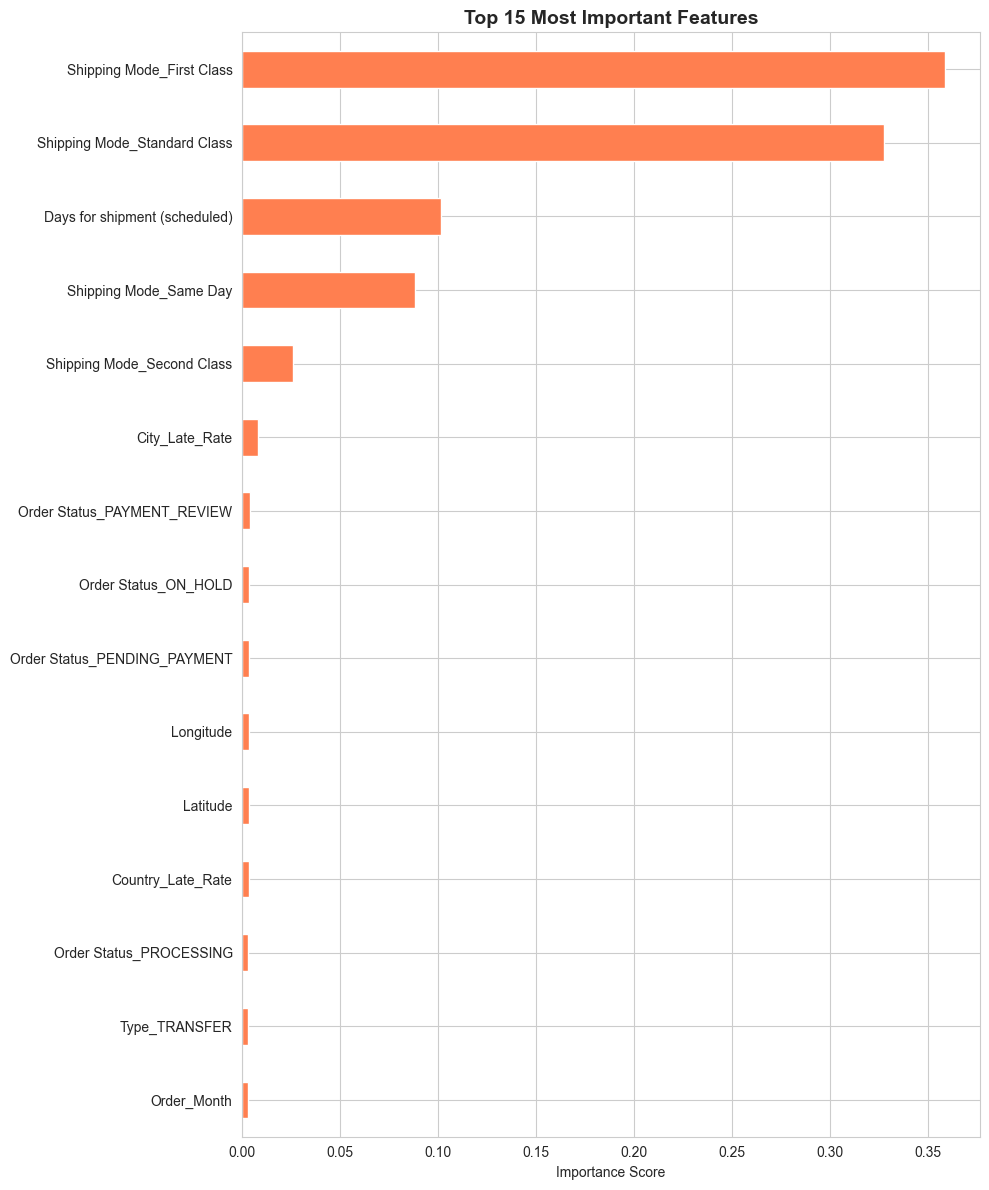

In [58]:
feature_importance = pd.Series(
    model_final.feature_importances_,
    index=final_features
).sort_values(ascending=True)

plt.figure(figsize=(10, 12))
feature_importance.tail(15).plot(kind='barh', color='coral')
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### What Drives Late Deliveries?
The model confirms my earlier findings. The top predictors are:
1. Shipping Mode (especially First Class and Standard Class)
2. Scheduled delivery days (the delivery promise)

Everything else, location, payment type, and order status have minimal impact.

The model and the exploratory analysis tell the same story: 
The company's delivery promises are the root cause of late deliveries, 
not the products, locations, or customers.

## Recommendations

Based on my analysis and model findings:

### 1. Fix Delivery Promises (Highest Priority)
- First Class promises 1 day but takes 2 — change the promise to 2 days
- Second Class promises 2 days but takes 4 — change the promise to 4 days
- This single change could reduce the "late delivery" rate from 55% 
  to under 20% overnight without changing anything about actual shipping

### 2. Audit First Class Shipping
- 95% of First Class orders are late — this is unacceptable for a premium service
- Either improve First Class speed or stop offering it until it can deliver on its promise

### 3. Investigate Transfer Payment Cancellations
- 16% of transfer orders are canceled vs 0% for other payment types
- This suggests a payment processing issue that needs fixing

### 4. Deploy the Prediction Model
- The model achieves F1 = 0.80 with 86% recall
- Use it to flag high-risk orders before shipping so the company can 
  take action (upgrade shipping, notify customer, adjust routing)

### 5. Collect More Data
- Track which delivery partners handle each shipment
- This would allow deeper investigation into whether specific couriers 
  are causing delays

## Project Summary

This project analyzed 180,000+ orders from a global supply chain company 
to understand and predict late deliveries.

### Key Findings
- 55% of all orders are delivered late — a company-wide systemic issue
- The root cause is unrealistic delivery promises, not slow shipping
- First Class shipping promises 1 day but takes 2 (95% late rate)
- Late deliveries are evenly spread across all regions, categories, 
  and customer segments — confirming it is a system-wide problem

### Model Performance
- Built an XGBoost model achieving F1 = 0.80 with 86% recall
- Improved from initial F1 of 0.68 through feature engineering, 
  model selection, and threshold optimization

### Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost